In [68]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, f1_score
from xgboost import XGBRegressor, XGBClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
# from surprise import Dataset, Reader, SVD, accuracy
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import joblib


from sklearn.linear_model import LinearRegression

In [3]:
# import pandas as pd

# pd.read_excel("User.xlsx", sheet_name="User").to_csv("User.csv", index=False)
# pd.read_excel("Transaction.xlsx", sheet_name="Transaction").to_csv("Transaction.csv", index=False)
# pd.read_excel("Type.xlsx", sheet_name="Types").to_csv("Type.csv", index=False)
# pd.read_excel("Mode.xlsx", sheet_name="VisitingMode").to_csv("Mode.csv", index=False)
# pd.read_excel("City.xlsx", sheet_name="Cities").to_csv("City.csv", index=False)
# pd.read_excel("Continent.xlsx", sheet_name="Continents").to_csv("Continent.csv", index=False)
# pd.read_excel("Region.xlsx", sheet_name="Regions").to_csv("Region.csv", index=False)
# pd.read_excel("Country.xlsx", sheet_name="Countries").to_csv("Country.csv", index=False)
# pd.read_excel("Item.xlsx", sheet_name="Item").to_csv("Item.csv", index=False)
# pd.read_excel("Updated_Item.xlsx", sheet_name="Sheet1").to_csv("Updated_Item.csv", index=False)


In [4]:
user_df = pd.read_csv("User.csv")
transaction_df = pd.read_csv("Transaction.csv")
type_df = pd.read_csv("Type.csv")
mode_df = pd.read_csv("Mode.csv")
city_df = pd.read_csv("City.csv")
continent_df = pd.read_csv("Continent.csv")
region_df = pd.read_csv("Region.csv")
country_df = pd.read_csv("Country.csv")
update_df = pd.read_csv("Updated_Item.csv")
item_df = pd.read_csv("Item.csv")

## Merging:

In [5]:
location = (city_df.merge(country_df, on='CountryId', how='left').merge(region_df, on='RegionId', how='left').merge(continent_df, on='ContinentId', how='left'))

In [6]:
merge_df = transaction_df.merge(mode_df, left_on='VisitMode', right_on='VisitModeId', how='left', suffixes=('', '_mode'))

In [7]:
merge_df = merge_df.drop(columns=['VisitModeId'])

In [8]:
merge_df = merge_df.merge(update_df, on='AttractionId', how='left')

In [9]:
merge_df['AttractionTypeId'] = merge_df['AttractionTypeId'].astype('Int64')

In [10]:
merge_df = merge_df.merge(type_df, on='AttractionTypeId', how='left')

In [11]:
attraction_location = location.add_prefix('Attraction')

In [12]:
merge_df = merge_df.merge(attraction_location, on='AttractionCityId', how='left')

In [13]:
merge_df = merge_df.merge(user_df, on='UserId', how='left')

In [14]:
merge_df['CityId'] = merge_df['CityId'].astype('Int64')

In [15]:
user_location = location.add_prefix('User')

In [16]:
merge_df = merge_df.merge(user_location, left_on='CityId', right_on='UserCityId', how='left')

In [17]:
merge_df = merge_df.drop(columns=['ContinentId', 'RegionId', 'CountryId', 'CityId'])

In [18]:
merge_df.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating', 'VisitMode_mode', 'AttractionCityId',
       'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType',
       'AttractionCityName', 'AttractionCountryId', 'AttractionCountry',
       'AttractionRegionId', 'AttractionRegion', 'AttractionContinentId',
       'AttractionContinent', 'UserCityId', 'UserCityName', 'UserCountryId',
       'UserCountry', 'UserRegionId', 'UserRegion', 'UserContinentId',
       'UserContinent'],
      dtype='object')

In [19]:
merge_df.dropna(inplace=True)
merge_df = merge_df.drop_duplicates()

In [20]:
merge_df = merge_df[~(
    (merge_df['UserRegion'] == '-') &
    (merge_df['UserContinent'] == '-'))
]

## EDA

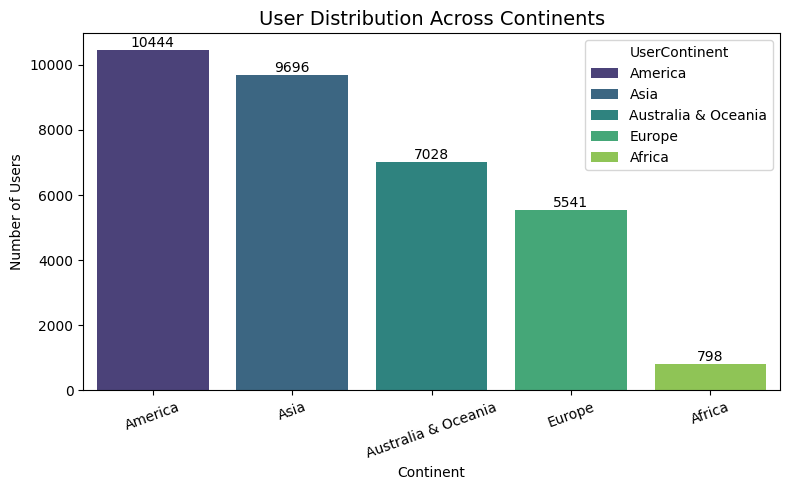

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count unique users in each continent
continent_users = (
    merge_df.groupby("UserContinent")["UserId"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=continent_users.index,
    y=continent_users.values,
    hue=continent_users.index,
    palette="viridis",
    legend=True
)

plt.title("User Distribution Across Continents", fontsize=14)
plt.xlabel("Continent")
plt.ylabel("Number of Users")
plt.xticks(rotation=20)

for i, v in enumerate(continent_users.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

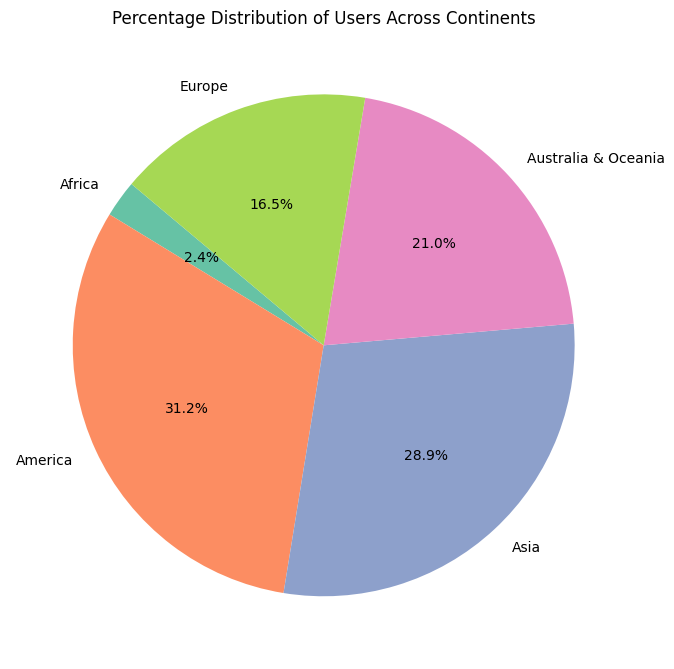

In [56]:
continent_users = (
    merge_df.groupby("UserContinent")["UserId"]
      .nunique()
)

plt.figure(figsize=(7,7))

plt.pie(
    continent_users.values,
    labels=continent_users.index,
    autopct="%1.1f%%",
    startangle=140,
    colors = plt.cm.Set2.colors
)

plt.title("Percentage Distribution of Users Across Continents")
plt.tight_layout()
plt.show()

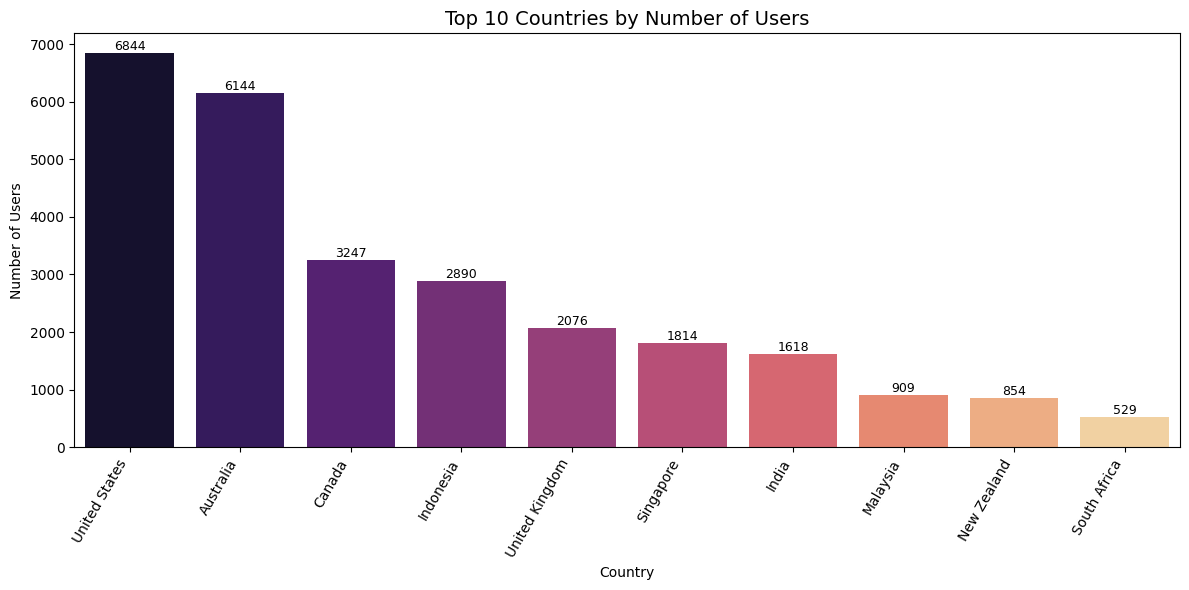

In [51]:
country_users = (
    merge_df.groupby("UserCountry")["UserId"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_users.index,
    y=country_users.values,
    hue=country_users.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Countries by Number of Users", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Number of Users")
plt.xticks(rotation=60, ha='right')

for i, v in enumerate(country_users.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

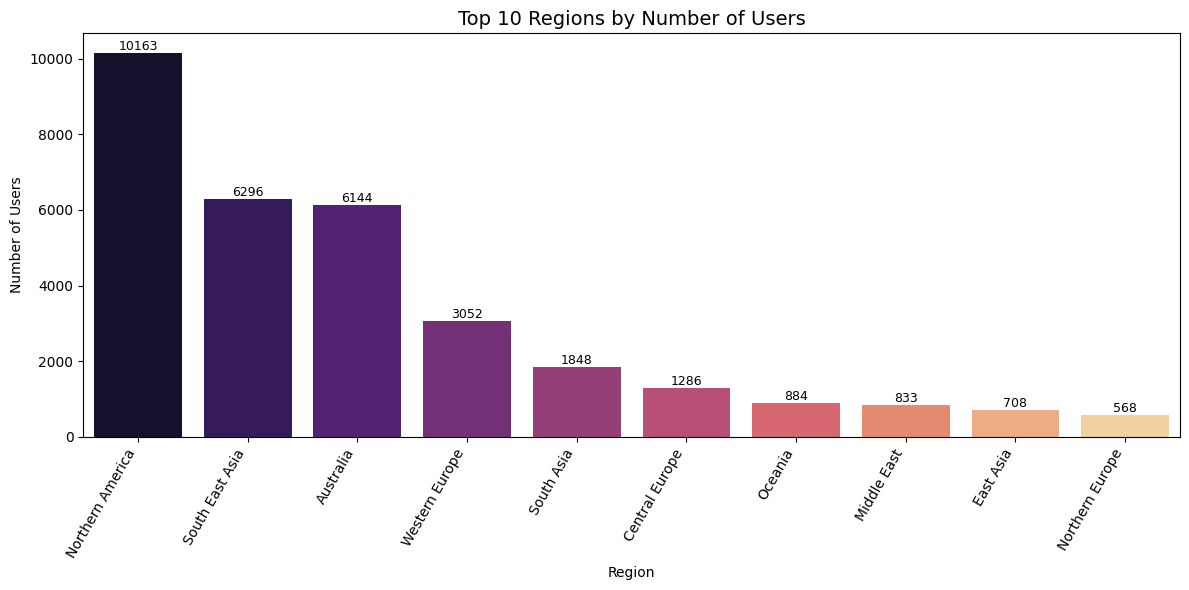

In [52]:
country_users = (
    merge_df.groupby("UserRegion")["UserId"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_users.index,
    y=country_users.values,
    hue=country_users.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Regions by Number of Users", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Number of Users")
plt.xticks(rotation=60, ha='right')

for i, v in enumerate(country_users.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

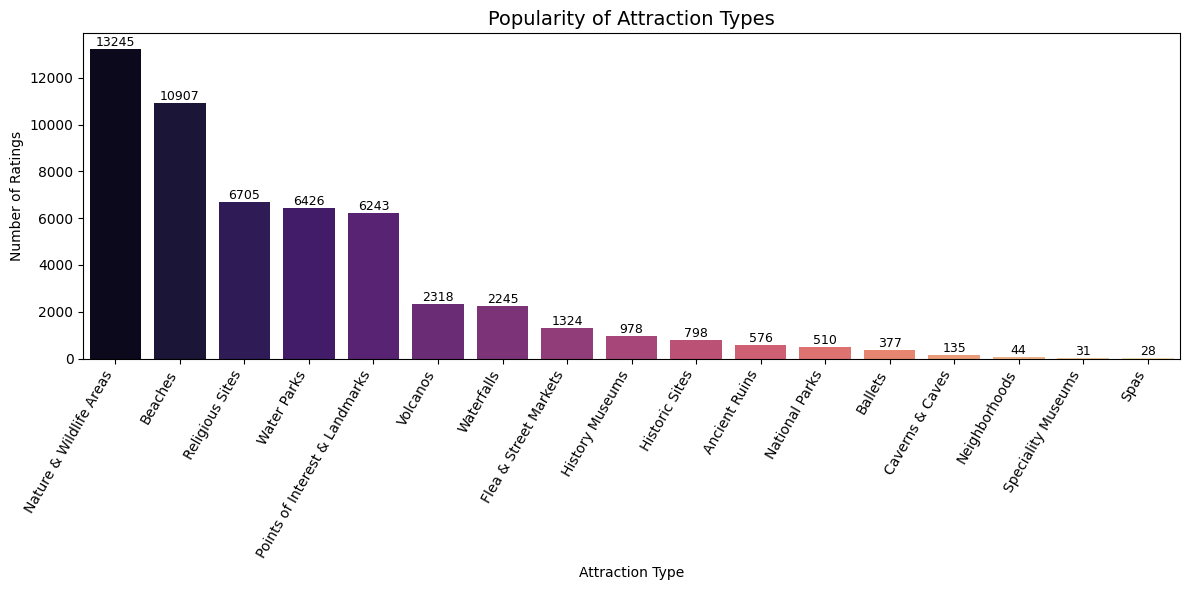

In [57]:
rating_count = (
    merge_df.groupby("AttractionType")["Rating"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=rating_count.index,
    y=rating_count.values,
    hue=rating_count.index,
    palette="magma",
    legend=False
)

plt.title("Popularity of Attraction Types", fontsize=14)
plt.xlabel("Attraction Type")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=60, ha="right")

for i, v in enumerate(rating_count.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

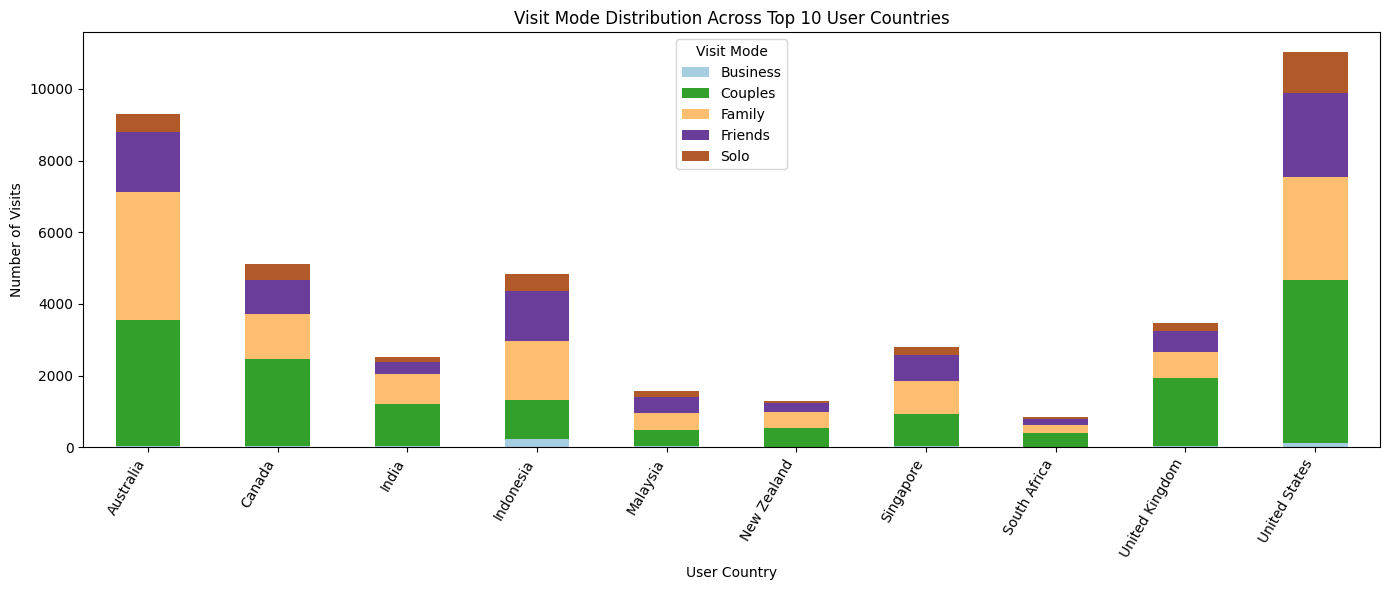

In [39]:
top_countries = merge_df["UserCountry"].value_counts().head(10).index

country_df = merge_df[merge_df["UserCountry"].isin(top_countries)]

country_visit = pd.crosstab(
    country_df["UserCountry"],
    country_df["VisitMode_mode"]
)

country_visit.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6),
    colormap="Paired"
)

plt.title("Visit Mode Distribution Across Top 10 User Countries")
plt.xlabel("User Country")
plt.ylabel("Number of Visits")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Visit Mode")
plt.tight_layout()
plt.show()

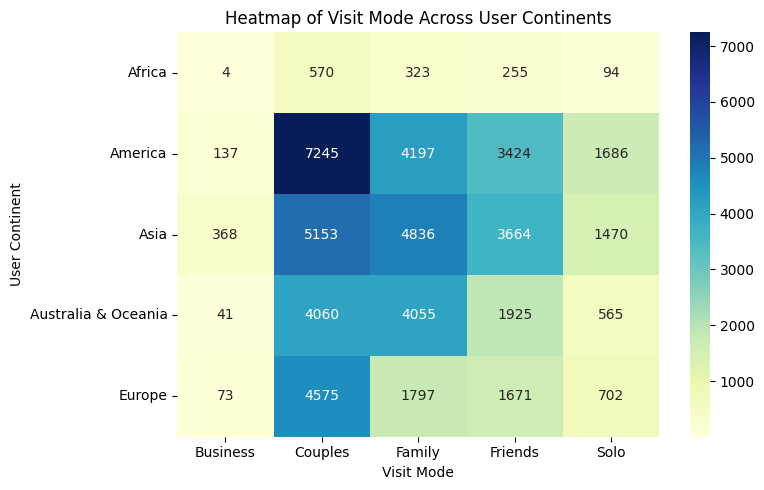

In [33]:
import seaborn as sns

continent_visit = pd.crosstab(
    merge_df["UserContinent"],
    merge_df["VisitMode_mode"]
)

plt.figure(figsize=(8,5))

sns.heatmap(
    continent_visit,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Heatmap of Visit Mode Across User Continents")
plt.xlabel("Visit Mode")
plt.ylabel("User Continent")
plt.tight_layout()
plt.show()

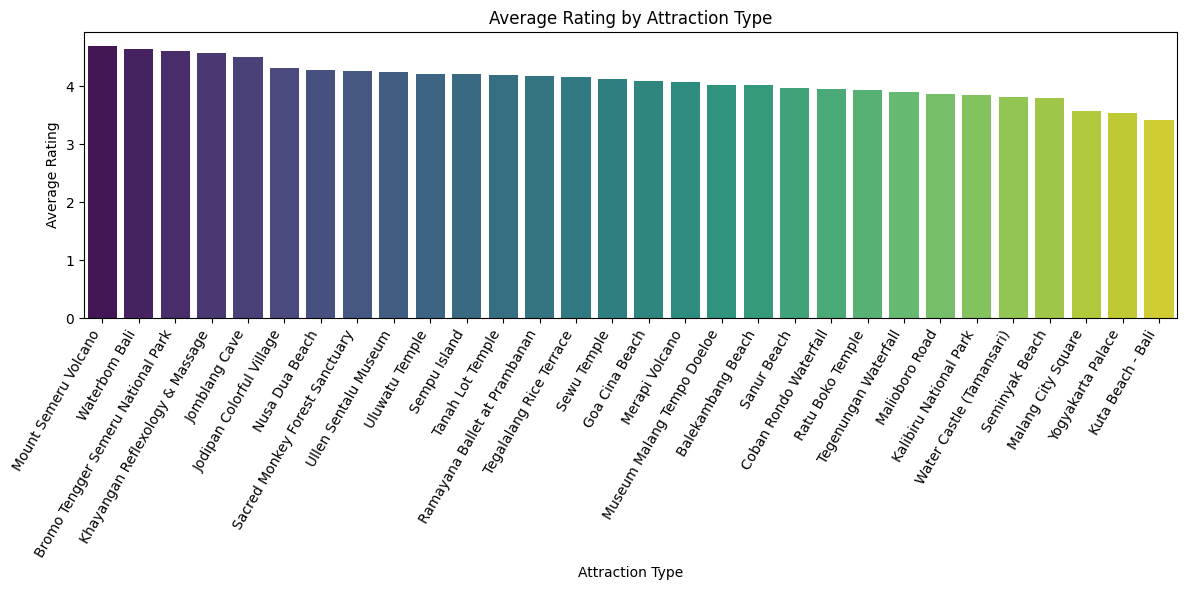

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_rating = (
    merge_df.groupby("Attraction")["Rating"]
            .mean()
            .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values,
    hue=avg_rating.index,
    palette="viridis",
    legend=False
)

plt.title("Average Rating by Attraction Type")
plt.xlabel("Attraction Type")
plt.ylabel("Average Rating")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

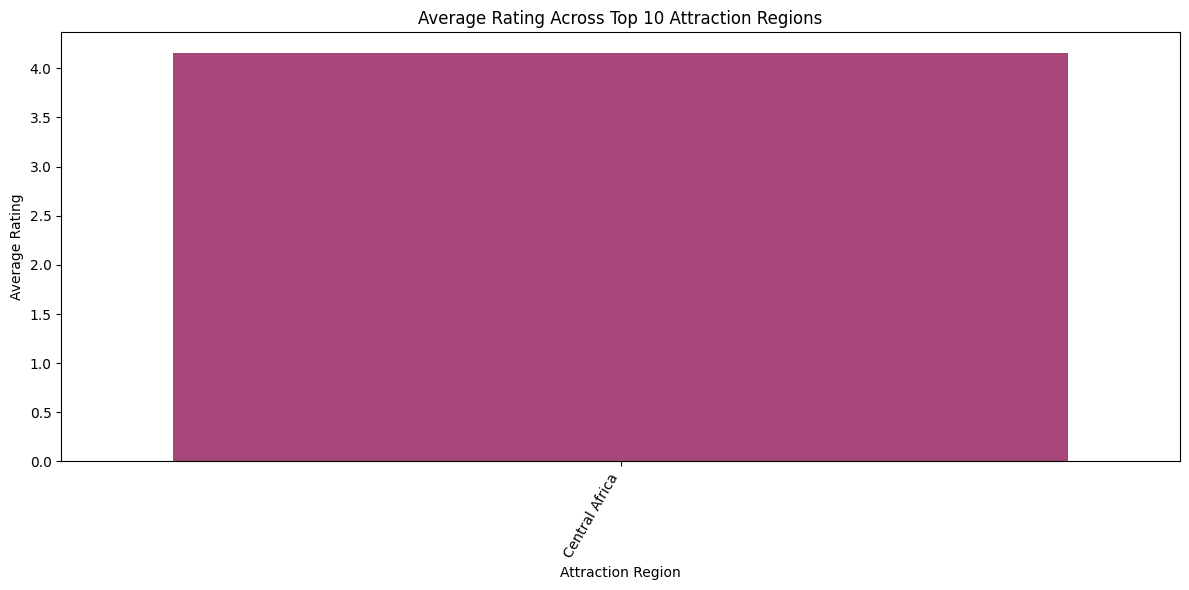

In [59]:
top_regions = merge_df["AttractionRegion"].value_counts().head(10).index

region_df = merge_df[
    merge_df["AttractionRegion"].isin(top_regions)
]

avg_region_rating = (
    region_df.groupby("AttractionRegion")["Rating"]
             .mean()
             .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_region_rating.index,
    y=avg_region_rating.values,
    hue=avg_region_rating.index,
    palette="magma",
    legend=False
)

plt.title("Average Rating Across Top 10 Attraction Regions")
plt.xlabel("Attraction Region")
plt.ylabel("Average Rating")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

## Regression

In [28]:
clean_rating_df = merge_df[['TransactionId','UserId',
       'VisitYear', 'VisitMonth','UserCityName','UserCityId',
       'UserCountry', 'UserCountryId', 'UserRegion', 'UserRegionId',
       'UserContinent','UserContinentId','Attraction','AttractionId','AttractionType','AttractionTypeId',
       'AttractionCityName','AttractionCityId', 'AttractionCountry','AttractionCountryId',
        'AttractionRegion','AttractionRegionId', 'AttractionContinent','AttractionContinentId','VisitMode_mode','VisitMode', 'Rating']].copy()

In [29]:
def get_season(month):

    if month in [12,1,2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autum'
    

clean_rating_df['Season'] = clean_rating_df['VisitMonth'].apply(get_season)

In [30]:
clean_rating_df['UserVisitCount'] = clean_rating_df.groupby('UserId')['TransactionId'].transform('count')

clean_rating_df['AttractionAvgRating'] = clean_rating_df.groupby('AttractionId')['Rating'].transform('mean')

clean_rating_df['UserAvgRating'] = clean_rating_df.groupby('UserId')['Rating'].transform('mean')

clean_rating_df['VisitModeAvgRating'] = clean_rating_df.groupby('VisitMode_mode')['Rating'].transform('mean')

clean_rating_df['UniqueAttractionVisited'] = clean_rating_df.groupby('UserId')['AttractionId'].transform('nunique')

In [31]:
clean_rating_df.isnull().sum()

TransactionId              0
UserId                     0
VisitYear                  0
VisitMonth                 0
UserCityName               0
UserCityId                 0
UserCountry                0
UserCountryId              0
UserRegion                 0
UserRegionId               0
UserContinent              0
UserContinentId            0
Attraction                 0
AttractionId               0
AttractionType             0
AttractionTypeId           0
AttractionCityName         0
AttractionCityId           0
AttractionCountry          0
AttractionCountryId        0
AttractionRegion           0
AttractionRegionId         0
AttractionContinent        0
AttractionContinentId      0
VisitMode_mode             0
VisitMode                  0
Rating                     0
Season                     0
UserVisitCount             0
AttractionAvgRating        0
UserAvgRating              0
VisitModeAvgRating         0
UniqueAttractionVisited    0
dtype: int64

In [32]:
clean_rating_df.dropna(inplace=True)
clean_rating_df = clean_rating_df.drop_duplicates()

In [33]:
clean_rating_df = clean_rating_df[~(
    (clean_rating_df['UserRegion'] == '-') &
    (clean_rating_df['UserContinent'] == '-'))
]

In [34]:
columns_to_convert = ['UserCityId', 'UserCountryId', 'UserRegionId', 'UserContinentId']

clean_rating_df[columns_to_convert] = clean_rating_df[columns_to_convert].astype(int)

In [35]:
clean_rating_df.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'UserCityName',
       'UserCityId', 'UserCountry', 'UserCountryId', 'UserRegion',
       'UserRegionId', 'UserContinent', 'UserContinentId', 'Attraction',
       'AttractionId', 'AttractionType', 'AttractionTypeId',
       'AttractionCityName', 'AttractionCityId', 'AttractionCountry',
       'AttractionCountryId', 'AttractionRegion', 'AttractionRegionId',
       'AttractionContinent', 'AttractionContinentId', 'VisitMode_mode',
       'VisitMode', 'Rating', 'Season', 'UserVisitCount',
       'AttractionAvgRating', 'UserAvgRating', 'VisitModeAvgRating',
       'UniqueAttractionVisited'],
      dtype='object')

In [36]:
df = clean_rating_df[
    [
        "VisitYear",
        "VisitMonth",
        "VisitMode_mode",
        "Attraction",
        "UserContinent",
        "UserRegion",
        "UserCountry",
        "Season",
        "UserVisitCount",
        "AttractionAvgRating",
        "UserAvgRating",
        "VisitModeAvgRating",
        "UniqueAttractionVisited",
        "AttractionType",
        "Rating"
    ]]

In [37]:
X = df.drop('Rating', axis=1)
y = df['Rating']

In [38]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore')

X_encoded = ohe.fit_transform(X)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [40]:
model = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,random_state=7)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [41]:
forest_model = RandomForestRegressor(n_estimators=200,max_depth=8,random_state=7)
forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [42]:
xg_prediction = model.predict(X_test)
forest_prediction = forest_model.predict(X_test)

In [43]:
rmse = np.sqrt(mean_squared_error(y_test, forest_prediction))
r2 = r2_score(y_test, forest_prediction)

print("Random Forest Results")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Random Forest Results
RMSE: 0.5514
R2 Score: 0.6725


In [44]:
rmse = np.sqrt(mean_squared_error(y_test, xg_prediction))
r2 = r2_score(y_test, xg_prediction)

print("XGBRegressor Results")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

XGBRegressor Results
RMSE: 0.5026
R2 Score: 0.7279


In [45]:
xg_prediction = model.predict(X_train)
forest_prediction = forest_model.predict(X_train)

In [46]:
rmse = np.sqrt(mean_squared_error(y_train, forest_prediction))
r2 = r2_score(y_train, forest_prediction)

print("Random Forest Results")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Random Forest Results
RMSE: 0.5528
R2 Score: 0.6768


In [47]:
rmse = np.sqrt(mean_squared_error(y_train, xg_prediction))
r2 = r2_score(y_train, xg_prediction)

print("XGBRegressor Results")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

XGBRegressor Results
RMSE: 0.4814
R2 Score: 0.7549


 ## Classification

In [76]:
clean_mode_df = merge_df[['UserId','TransactionId',
       'VisitYear', 'VisitMonth','UserCityName','UserCityId',
       'UserCountry', 'UserCountryId', 'UserRegion', 'UserRegionId','Attraction', 'AttractionId',
       'UserContinent','UserContinentId','AttractionType','AttractionTypeId',
       'AttractionCityName','AttractionCityId', 'AttractionCountry','AttractionCountryId',
        'AttractionRegion','AttractionRegionId', 'AttractionContinent','AttractionContinentId','VisitMode_mode','VisitMode']].copy()

In [77]:
def get_season(month):

    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autum'
    

clean_mode_df['Season'] = clean_mode_df['VisitMonth'].apply(get_season)

In [78]:
clean_mode_df['UserVisitCount'] = clean_mode_df.groupby('UserId')['TransactionId'].transform('count')

clean_mode_df['UniqueAttractionVisited'] = clean_mode_df.groupby('UserId')['AttractionId'].transform('nunique')

clean_mode_df['AttractionTypePopularity'] = clean_mode_df.groupby('AttractionType')['TransactionId'].transform('count')

clean_mode_df['AttractionPopularity'] = clean_mode_df.groupby('AttractionId')['TransactionId'].transform('count')

clean_mode_df['HistoricalVisitCount'] = clean_mode_df.groupby(['VisitYear', 'VisitMonth'])['TransactionId'].transform('count')

In [79]:
clean_mode_df = clean_mode_df.drop_duplicates()

In [80]:
clean_mode_df.dropna(inplace=True)

In [81]:
df = clean_mode_df[["VisitYear",
        "VisitMonth",
        "UserContinent",
        "UserRegion",
        "UserCountry",
        "UserCityName",
        "AttractionType",
        'Season',
        "VisitMode_mode",
        "HistoricalVisitCount",
        'UniqueAttractionVisited']]

In [94]:
from sqlalchemy import create_engine
import psycopg2

host = "localhost"
port = "5432"
database = "tourism_mode"
username = "postgres"
password = "password"

In [ ]:
# import psycopg2

# connection = psycopg2.connect(
#     dbname=database,
#     user=username,
#     password=password,
#     host=host,
#     port=port
# )

# cursor = connection.cursor()

# cursor.execute("""
#     CREATE TABLE visit_mode_prediction (

#         VisitYear INTEGER,
#         VisitMonth INTEGER,
#         UserContinent TEXT,
#         UserRegion TEXT,
#         UserCountry TEXT,
#         UserCityName TEXT,
#         AttractionType TEXT,
#         Season TEXT,
#         VisitMode_mode TEXT,
#         HistoricalVisitCount INTEGER,
#         UniqueAttractionVisited INTEGER

#     )
# """)

# connection.commit()

# cursor.close()
# connection.close()

# print("Table created successfully!")

Table created successfully!


In [102]:
df.head()

,visityear,visitmonth,usercontinent,userregion,usercountry,usercityname,attractiontype,season,visitmode_mode,historicalvisitcount,uniqueattractionvisited
0,2022,10,Australia & Oceania,Australia,Australia,Guildford,Nature & Wildlife Areas,Autum,Couples,25,1
1,2022,10,America,Northern America,Canada,Ontario,Nature & Wildlife Areas,Autum,Friends,25,1
2,2022,10,America,Northern America,United States,Brazil,Nature & Wildlife Areas,Autum,Family,25,1
3,2022,10,America,Northern America,Canada,Zurich,Nature & Wildlife Areas,Autum,Family,25,1
4,2022,10,America,Northern America,United States,Manchester,Nature & Wildlife Areas,Autum,Couples,25,3


In [101]:
df.columns = df.columns.str.lower()

In [ ]:
# from sqlalchemy import create_engine

# engine_string = (
#     f"postgresql://{username}:{password}@{host}:{port}/{database}"
# )

# engine = create_engine(engine_string)

# df.to_sql(
#     "visit_mode_prediction",
#     engine,
#     if_exists="append",
#     index=False
# )

# print("Data successfully pushed to PostgreSQL!")

Data successfully pushed to PostgreSQL!


In [82]:
X = df.drop(columns='VisitMode_mode', axis=1)
y = df['VisitMode_mode']

In [83]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore')

X_encoded = ohe.fit_transform(X)

In [84]:
joblib.dump(ohe, "onehot_encoder.pkl")

['onehot_encoder.pkl']

In [85]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [86]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42,stratify=y)

In [88]:
model = XGBClassifier(n_estimators=200, max_depth=15, learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,objective="multi:softmax",random_state=7)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [89]:
joblib.dump(model, "visit_mode_model.pkl")

['visit_mode_model.pkl']

In [61]:
forest_model = RandomForestClassifier(n_estimators=200,max_depth=15,random_state=7)
forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [62]:
xg_prediction = model.predict(X_test)
forest_prediction = forest_model.predict(X_test)

In [63]:
acc = accuracy_score(y_test, forest_prediction)
macro_f1 = f1_score(y_test, forest_prediction, average="macro")

print("Random Forest Results")
print(f"ACC: {acc:.4f}")
print(f"macro_f1: {macro_f1:.4f}")

Random Forest Results
ACC: 0.4609
macro_f1: 0.1935


In [64]:
acc = accuracy_score(y_test, xg_prediction)
macro_f1 = f1_score(y_test, xg_prediction, average="macro")

print("XGBRegressor Results")
print(f"ACC: {acc:.4f}")
print(f"macro_f1: {macro_f1:.4f}")

XGBRegressor Results
ACC: 0.5104
macro_f1: 0.3127


In [65]:
xg_trainprediction = model.predict(X_train)
forest_trainprediction = forest_model.predict(X_train)

In [66]:
acc = accuracy_score(y_train, forest_trainprediction)
macro_f1 = f1_score(y_train, forest_trainprediction, average="macro")

print("Random Forest Results")
print(f"ACC: {acc:.4f}")
print(f"macro_f1: {macro_f1:.4f}")

Random Forest Results
ACC: 0.4771
macro_f1: 0.2060


In [67]:
acc = accuracy_score(y_train, xg_trainprediction)
macro_f1 = f1_score(y_train, xg_trainprediction, average="macro")

print("XGBRegressor Results")
print(f"ACC: {acc:.4f}")
print(f"macro_f1: {macro_f1:.4f}")

XGBRegressor Results
ACC: 0.5951
macro_f1: 0.4304


## Recommendation:

In [133]:
merged_df = transaction_df.merge(user_df, how='left', on='UserId').merge(continent_df, how='left', on='ContinentId').merge(region_df, how='left', on='RegionId').merge(country_df, how='left', on='CountryId').merge(city_df, how='left', on='CityId').merge(mode_df, left_on='VisitMode', right_on='VisitModeId').merge(item_df, how='left', on='AttractionId').merge(type_df, how='left', on='AttractionTypeId')

In [134]:
merged_df.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode_x',
       'AttractionId', 'Rating', 'ContinentId_x', 'RegionId_x', 'CountryId_x',
       'CityId', 'Continent', 'Region', 'ContinentId_y', 'Country',
       'RegionId_y', 'CityName', 'CountryId_y', 'VisitModeId', 'VisitMode_y',
       'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress', 'AttractionType'],
      dtype='object')

In [135]:
attraction_info = merged_df[
    ['AttractionId', 'Attraction']
].drop_duplicates()

In [136]:
clean_recommend_df = merged_df[['UserId', 'AttractionId', 'Rating']]

In [137]:
clean_recommend_df.head()

,UserId,AttractionId,Rating
0,70456,640,5
1,7567,640,5
2,79069,640,5
3,31019,640,3
4,43611,640,3


In [138]:
clean_recommend_df.shape

(52930, 3)

In [139]:
clean_recommend_df = clean_recommend_df.drop_duplicates()

In [140]:
clean_recommend_df.shape

(47497, 3)

In [141]:
clean_recommend_df = clean_recommend_df.groupby(by=['UserId', 'AttractionId'], as_index=False).agg({'Rating': 'mean'})

In [142]:
clean_recommend_df.head()

,UserId,AttractionId,Rating
0,14,640,4.0
1,14,748,5.0
2,16,481,5.0
3,16,640,4.0
4,16,748,5.0


In [143]:
reader = Reader(rating_scale=(1, 5))

NameError: name 'Reader' is not defined

In [32]:
data = Dataset.load_from_df(
    clean_recommend_df[['UserId', 'AttractionId', 'Rating']],
    reader
)

In [33]:
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [34]:
svd = SVD(random_state=42)

In [35]:
svd.fit(trainset)

In [36]:
prediction = svd.test(testset)

In [37]:
from surprise import accuracy

accuracy.mse(prediction)


MSE: 0.8373


0.8373153996689923

In [ ]:
accuracy.rmse(prediction) 

RMSE: 0.9150


0.915049397392836

In [89]:
def collaborating_flitering(user_id, top_n):
    user_visited_attraction = clean_recommend_df[clean_recommend_df['UserId']==user_id]['AttractionId'].unique()

    all_attractionId = clean_recommend_df['AttractionId'].unique()

    unseen_attractionId = np.setdiff1d(all_attractionId,user_visited_attraction)

    prediction = []

    for attractionId in unseen_attractionId:
        rating = svd.predict(uid=user_id, iid=attractionId)
        prediction.append((attractionId, rating.est))

    predictions = sorted(prediction, key=lambda x: x[1], reverse=True)

    recommendation = pd.DataFrame(predictions[:top_n], columns=['AttractionId', 'PredictedRating'])

    final_recommendations=recommendation.merge(attraction_info, on='AttractionId', how='left')

    final_recommendations = final_recommendations[
        [
            'AttractionId',
            'Attraction',
            'PredictedRating'
        ]
    ]

    return final_recommendations

In [90]:
collaborating_flitering(18, 5)

,AttractionId,Attraction,PredictedRating
0,947,Mount Semeru Volcano,4.631605
1,841,Waterbom Bali,4.611009
2,888,Bromo Tengger Semeru National Park,4.597197
3,1133,Jomblang Cave,4.576199
4,928,Khayangan Reflexology & Massage,4.465936


## Content-Based Filtering:

In [60]:
merge_df.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating', 'VisitMode_mode', 'AttractionCityId',
       'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType',
       'AttractionCityName', 'AttractionCountryId', 'AttractionCountry',
       'AttractionRegionId', 'AttractionRegion', 'AttractionContinentId',
       'AttractionContinent', 'UserCityId', 'UserCityName', 'UserCountryId',
       'UserCountry', 'UserRegionId', 'UserRegion', 'UserContinentId',
       'UserContinent'],
      dtype='object')

In [63]:
clean_recommend_df.head()

,UserId,AttractionId,Rating
0,14,640,4.0
1,14,748,5.0
2,16,481,5.0
3,16,640,4.0
4,16,748,5.0


In [61]:
clean_content_df = merge_df[['AttractionId', 'Attraction', 'AttractionType', 'AttractionCityName','AttractionCountry']]

In [ ]:
clean_content_df.groupby("AttractionId")[
    ["Attraction", "AttractionType", "AttractionCityName", "AttractionCountry"]
].nunique()

In [66]:
clean_content_df = clean_content_df.drop_duplicates(
    subset=["AttractionId"]
).reset_index(drop=True)

In [ ]:
# Calculate attraction popularity
popularity_df = (
    clean_recommend_df
    .groupby("AttractionId")
    .agg(
        AvgRating=("Rating", "mean"),
        RatingCount=("Rating", "count")
    )
    .reset_index()
)

,AttractionId,AvgRating,RatingCount
0,369,3.404382,2571
1,481,4.270080,1992
2,640,4.262188,11487
3,650,3.969255,2808
4,673,3.804527,2754


In [70]:
content_df = clean_content_df.merge(
    popularity_df,
    on="AttractionId",
    how="left"
)

content_df.head()

,AttractionId,Attraction,AttractionType,AttractionCityName,AttractionCountry,AvgRating,RatingCount
0,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,4.262188,11487
1,841,Waterbom Bali,Water Parks,Douala,Cameroon,4.646090,5605
2,673,Seminyak Beach,Beaches,Douala,Cameroon,3.804527,2754
3,481,Nusa Dua Beach,Beaches,Douala,Cameroon,4.270080,1992
4,650,Sanur Beach,Beaches,Douala,Cameroon,3.969255,2808


In [71]:
content_df.isnull().sum()

AttractionId          0
Attraction            0
AttractionType        0
AttractionCityName    0
AttractionCountry     0
AvgRating             0
RatingCount           0
dtype: int64

In [ ]:
feature_columns = [
    "AttractionType",
    "AttractionCityName",
    "AttractionCountry"
]

content_features = content_df[feature_columns]

,AttractionType,AttractionCityName,AttractionCountry
0,Nature & Wildlife Areas,Douala,Cameroon
1,Water Parks,Douala,Cameroon
2,Beaches,Douala,Cameroon
3,Beaches,Douala,Cameroon
4,Beaches,Douala,Cameroon


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

encoded_features = encoder.fit_transform(content_features)

(30, 22)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(encoded_features)

In [75]:
attraction_index = pd.Series(
    content_df.index,
    index=content_df["AttractionId"]
)

attraction_index.head()

AttractionId
640    0
841    1
673    2
481    3
650    4
dtype: int64

In [97]:
def recommend_similar_attractions(attraction_id, top_n=5):

    # Get index of the selected attraction
    idx = attraction_index[attraction_id]

    # Compute similarity scores
    similarity_scores = list(enumerate(similarity_matrix[idx]))

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n + 1]

    recommendations = []

    for index, score in similarity_scores:

        recommendations.append({
            "Attraction": content_df.iloc[index]["Attraction"],
            "CityName": content_df.iloc[index]["AttractionCityName"],
            "Country": content_df.iloc[index]["AttractionCountry"],
            "AttractionType": content_df.iloc[index]["AttractionType"],
            "Rating": round(content_df.iloc[index]["AvgRating"], 2)
        })

    return pd.DataFrame(recommendations)

In [98]:
recommend_similar_attractions(640, top_n=5)

,Attraction,CityName,Country,AttractionType,Rating
0,Waterbom Bali,Douala,Cameroon,Water Parks,4.65
1,Seminyak Beach,Douala,Cameroon,Beaches,3.80
2,Nusa Dua Beach,Douala,Cameroon,Beaches,4.27
3,Sanur Beach,Douala,Cameroon,Beaches,3.97
4,Uluwatu Temple,Douala,Cameroon,Religious Sites,4.22
